assert 뒤의 내용이 참인지 확인

클래스종류마다 개수가 각각 차이가 많이 나면 학습에도 문제가 생길 수 있음 - 불균형
각각의 개수만큼 학습이 이루어지기 때문에 개수가 적으면 그만큼 학습이 적게 수행됨
-나중에 클래스의 개수를 맞춰주는 작업 필요

선형(연속) 데이터는 stratify를 쓰지 않음

클래스마다 데이터의 차이(특징)를 아는것이 중요, mean활용

각 변수별로 예측 중요도

# TODO 3-2: 종별 숫자형 변수 평균

numeric_cols = df.select_dtypes(include=['number']).columns
species_averages = df.groupby("species")[numeric_cols].mean()
print("종별 숫자형 변수 평균:\n{}".format(species_averages))

import seaborn as sns

plt.figure(figsize=(10,6))

feature간의 상관관계(자기상관관계)가 과하게 높은 데이터는 둘중 한 feature를 날리는게 좋을 수 있다.

# TODO 3-5: 상관계수 행렬과 히트맵

import numpy as np
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

regression_target = "body_mass_g"
regression_numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
regression_categorical_features = ["species", "island", "sex"]
regression_features = regression_numeric_features + regression_categorical_features

전처리 파이프라인
입력 데이터를 넣으면 이를 기반으로 가공된 데이터를 출력하도록 하는 흐름
# TODO 6-1

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

reg_numeric_transformer = Pipeline([("scaler", StandardScaler())])
reg_categorical_transformer = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_transformer, regression_numeric_features),
    ("categorical", reg_categorical_transformer, regression_categorical_features)
])
linear_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

# TODO 7-1 : X / y split, train / test split
regression_target = "body_mass_g"

X_reg = df[regression_numeric_features + regression_categorical_features]
y_reg = df[regression_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, 
    test_size=0.2, 
    random_state=42
)

# TODO 8-1 : 6단계에서 만든 `linear_model`을 학습하고, 테스트 데이터에서 MAE, RMSE, R²를 계산하세요.

lr = linear_model.fit(X_reg_train, y_reg_train)
y_pred_linear = lr.predict(X_reg_test)
linear_mse = mean_squared_error(y_reg_test, y_pred_linear)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_reg_test, y_pred_linear)

linear_metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})
print(f"Linear Regression - RMSE: {linear_rmse}, R2: {linear_r2}")

모델의 성능도 중요하지만 학습 시간이 짧게 걸리는 것도 중요하다

# TODO 11-1 : 테스트 데이터의 예측값과 잔차를 계산하고, 실제값과 예측값의 차이와 잔차를 확인 할 수 있도록 그래프를 그리세요.

linear_pred = lr.predict(X_reg_test)
linear_residuals = y_reg_test - linear_pred
residual_df = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": linear_pred,
    "residual": linear_residuals,
    "abs_residual": linear_residuals.abs()
})
display(residual_df.sort_values("abs_residual", ascending=False).head(10))

sns.scatterplot(x=residual_df["predicted"], y=residual_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Multiple Linear Regression")
plt.xlabel("predicted body_mass_g")
plt.ylabel("residual")
plt.show()


# TODO 11-1 : 테스트 데이터의 예측값과 잔차를 계산하고, 실제값과 예측값의 차이와 잔차를 확인 할 수 있도록 그래프를 그리세요.

linear_pred = lr.predict(X_reg_test)
linear_residuals = y_reg_test - linear_pred
residual_df = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": linear_pred,
    "residual": linear_residuals,
    "abs_residual": linear_residuals.abs()
})
display(residual_df.sort_values("abs_residual", ascending=False).head(10))

sns.scatterplot(x=residual_df["predicted"], y=residual_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Multiple Linear Regression")
plt.xlabel("predicted body_mass_g")
plt.ylabel("residual")
plt.show()


In [1]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [3]:
import seaborn as sns 

df = sns.load_dataset("penguins") 
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [10]:
df.dropna(subset=['sex'], inplace=True)

In [11]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [12]:
numeric_cols = df.select_dtypes(include=['number']).columns
species_averages = df.groupby("species")[numeric_cols].mean()
print("종별 숫자형 변수 평균:\n{}".format(species_averages))

import seaborn as sns

plt.figure(figsize=(10,6))

종별 숫자형 변수 평균:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

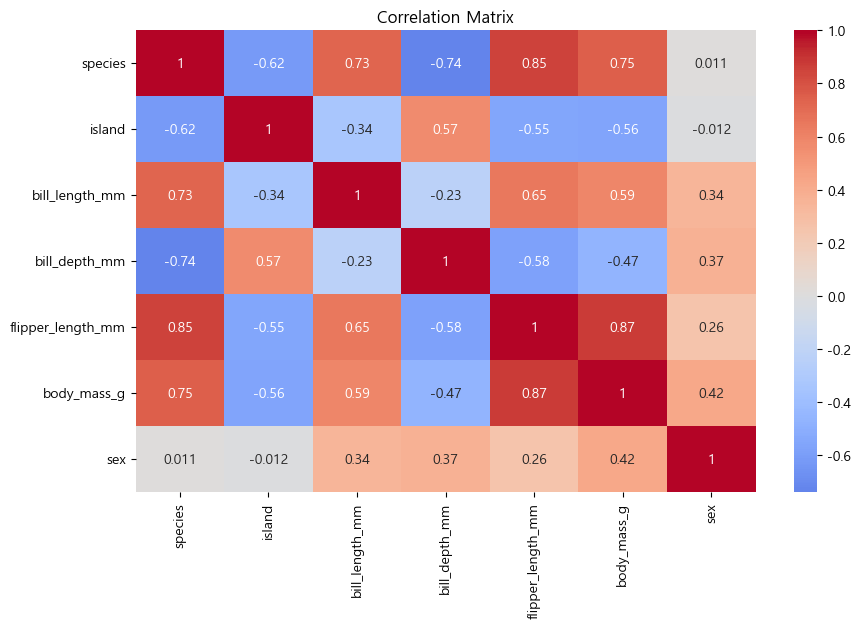

In [13]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

regression_target = "body_mass_g"
regression_numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
regression_categorical_features = ["species", "island", "sex"]
regression_features = regression_numeric_features + regression_categorical_features

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

reg_numeric_transformer = Pipeline([("scaler", StandardScaler())])
reg_categorical_transformer = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])
reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_transformer, regression_numeric_features),
    ("categorical", reg_categorical_transformer, regression_categorical_features)
])
linear_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

In [15]:
regression_target = "body_mass_g"

X_reg = df[regression_numeric_features + regression_categorical_features]
y_reg = df[regression_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, 
    test_size=0.2, 
    random_state=42
)

In [16]:
lr = linear_model.fit(X_reg_train, y_reg_train)
y_pred_linear = lr.predict(X_reg_test)
linear_mse = mean_squared_error(y_reg_test, y_pred_linear)
linear_rmse = linear_mse ** 0.5
linear_r2 = r2_score(y_reg_test, y_pred_linear)

linear_metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [linear_rmse],
    "R2": [linear_r2]
})
print(f"Linear Regression - RMSE: {linear_rmse}, R2: {linear_r2}")

Linear Regression - RMSE: 255.74907911734914, R2: 0.8961688345769453


,actual,predicted,residual,abs_residual
81,4700.0,3957.650255,742.349745,742.349745
260,3950.0,4585.405037,-635.405037,635.405037
119,3325.0,3886.545936,-561.545936,561.545936
235,5850.0,5361.205214,488.794786,488.794786
187,3900.0,3454.962919,445.037081,445.037081
116,2900.0,3330.284573,-430.284573,430.284573
268,5100.0,4672.904426,427.095574,427.095574
82,3800.0,3402.842112,397.157888,397.157888
331,5950.0,5566.850930,383.149070,383.149070
51,4300.0,3926.530576,373.469424,373.469424


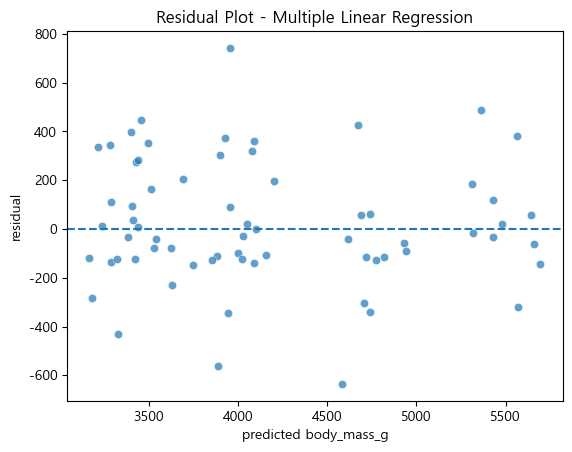

In [17]:
linear_pred = lr.predict(X_reg_test)
linear_residuals = y_reg_test - linear_pred
residual_df = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": linear_pred,
    "residual": linear_residuals,
    "abs_residual": linear_residuals.abs()
})
display(residual_df.sort_values("abs_residual", ascending=False).head(10))

sns.scatterplot(x=residual_df["predicted"], y=residual_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Multiple Linear Regression")
plt.xlabel("predicted body_mass_g")
plt.ylabel("residual")
plt.show()

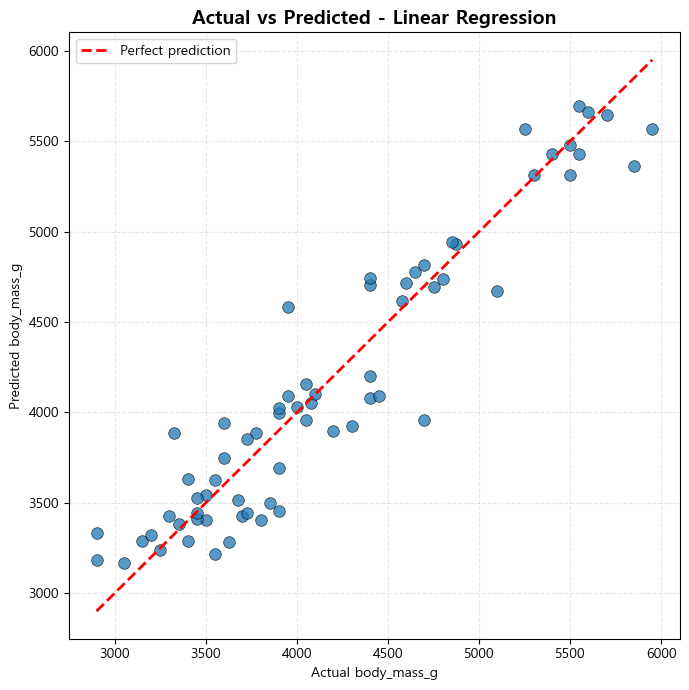

In [21]:
linear_pred = lr.predict(X_reg_test)

plot_df = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": linear_pred
})

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=plot_df,
    x="actual",
    y="predicted",
    alpha=0.75,
    s=70,
    edgecolor="black",
    linewidth=0.5
)

min_value = min(plot_df["actual"].min(), plot_df["predicted"].min())
max_value = max(plot_df["actual"].max(), plot_df["predicted"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.title("Actual vs Predicted - Linear Regression", fontsize=14, fontweight="bold")
plt.xlabel("Actual body_mass_g")
plt.ylabel("Predicted body_mass_g")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()